# Configurable Grid — Theoretical Segregation Metrics

Build a **rows × cols** grid where every cell holds a *blue* and *red* population count, visualise it, and run the full suite of segregation metrics from `pipeline/metrics.py`.

**Quick start:** edit the `CONFIGURATION` cell, then *Kernel → Restart & Run All*.

| Mode | Key params | Description |
|------|-----------|-------------|
| `"random"` | `RANDOM_SEED` | each cell gets a uniformly random blue / red split |
| `"gradient"` | — | linear sweep left → right: leftmost column = all blue, rightmost = all red |
| `"checkerboard"` | — | strict (r+c) % 2 checkerboard |
| `"checkerboard_perturbed"` | `PERTURB_PROB` | checkerboard base; cells walked in raster order — each cell independently adopts its predecessor's colour with probability `PERTURB_PROB`, otherwise keeps its checkerboard colour. Low prob ≈ *low* segregation; higher prob → *medium* |
| `"blobs"` | `BLOB_SIZE` | Gaussian-smoothed white noise, thresholded at the median. `BLOB_SIZE` is the Gaussian σ (cells). Small → fine salt-and-pepper; large → smooth organic blobs (*high* segregation) |

In [146]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import gerrychain
from pathlib import Path

# ── Locate project root and import pipeline.metrics ────────────────────────────
PROJECT_ROOT = (Path.cwd() / "../../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pipeline.metrics as m

# ── Compatibility patch ────────────────────────────────────────────────────────
# pipeline/metrics.py uses @functools.cache on functions that take a
# gerrychain.Graph.  networkx.Graph defines __eq__ without __hash__, so it is
# unhashable by default.  We patch in an id-based hash: safe as long as we
# clear the cache (done in the Build cell) whenever we switch to a new grid.
if gerrychain.Graph.__hash__ is None:
    gerrychain.Graph.__hash__ = lambda self: id(self)

print(f"✓ imports OK  |  project root: {PROJECT_ROOT}")

✓ imports OK  |  project root: /Users/maria/Documents/capy-bara


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                           CONFIGURATION                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Grid layout ────────────────────────────────────────────────────────────────
ROWS = 10               # number of rows
COLS = 10               # number of columns
CELL_POPULATION = 100   # total "residents" per cell (sets count precision)

# ── Color / population mode ────────────────────────────────────────────────────
#   "random"                 – each cell gets a uniformly random blue/red split
#   "gradient"               – linear sweep: leftmost column = all blue, rightmost = all red
#   "checkerboard"           – strict (r+c) % 2 checkerboard
#   "checkerboard_perturbed" – checkerboard + raster walk; each cell adopts its
#                              predecessor's colour with prob PERTURB_PROB
#                              (low ≈ 0.1–0.2  →  medium ≈ 0.4–0.6)
#   "blobs"                  – Gaussian-smoothed noise thresholded at median;
#                              BLOB_SIZE is the Gaussian σ in cells
#                              (small ≈ 1–2  →  large blobs ≈ 4–8)
MODE = "checkerboard_perturbed"

RANDOM_SEED = 42 # RNG seed (used by random, checkerboard_perturbed, blobs)

# ── Mode-specific parameters ───────────────────────────────────────────────────
PERTURB_PROB = 0.6     # checkerboard_perturbed: prob of adopting predecessor's colour
BLOB_SIZE    = 1        # blobs: Gaussian σ (cells); larger → bigger blobs

# ── Metric column names ────────────────────────────────────────────────────────
X_COL   = "BLUE"        # the 'x' group in the metrics paper
Y_COL   = "RED"         # the 'y' group
TOT_COL = "TOTAL"       # per-cell total population

In [148]:
def build_grid(rows, cols, mode, cell_pop=100, seed=42,
               perturb_prob=0.15, blob_size=4):
    """
    Build a gerrychain.Graph for a rows×cols 4-connected grid.

    Every node receives the attributes expected by pipeline/metrics.py:

        BLUE, RED, TOTAL          – the two groups and their sum
        TOTPOP, WHITE, BLACK, POC – aliases required by hardcoded calls in
                                    metrics.run_metrics / property_sum
        grid_pos                  – (row, col) tuple for visualization

    Parameters
    ----------
    rows, cols : int
    mode : {"random_binary", "random_continuous", "gradient",
            "checkerboard", "checkerboard_perturbed", "blobs"}
    cell_pop : int   total population assigned to every cell
    seed : int       RNG seed
    perturb_prob : float
        checkerboard_perturbed only.  Probability that a cell, when visited
        in raster order, adopts the colour of its immediate predecessor
        instead of its checkerboard colour.  Range [0, 1].
        ≈ 0.10–0.20 → "low" clustering;  ≈ 0.40–0.60 → "medium" clustering.
    blob_size : float
        blobs only.  Standard deviation (in cells) of the Gaussian filter
        applied to the white-noise field before thresholding.
        ≈ 1–2 → fine-grained mixing;  ≈ 4–8 → large organic blobs.

    Returns
    -------
    G : gerrychain.Graph  (4-connected grid adjacency)
    """
    nx_G = nx.grid_2d_graph(rows, cols)
    nx_G = nx.convert_node_labels_to_integers(nx_G, label_attribute="grid_pos")
    nodes = list(nx_G.nodes())
    n = len(nodes)

    # ── Compute per-node blue counts ───────────────────────────────────────────
    if mode == "random_binary":
        blue_arr = np.random.choice([0, cell_pop], size=n)

    elif mode == "random_continuous":
        rng = np.random.default_rng(seed)
        blue_arr = rng.integers(0, cell_pop + 1, size=n)   # uniform [0, cell_pop]

    elif mode == "gradient":
        # Sort nodes by column index; fraction decreases left → right
        pos = {nd: nx_G.nodes[nd]["grid_pos"] for nd in nodes}
        ordered = sorted(range(n), key=lambda i: pos[nodes[i]][1])
        fracs = np.linspace(1.0, 0.0, n)     # 1.0 = all blue, 0.0 = all red
        blue_arr = np.zeros(n, dtype=int)
        for rank, idx in enumerate(ordered):
            blue_arr[idx] = int(round(fracs[rank] * cell_pop))

    elif mode == "checkerboard":
        pos = {nd: nx_G.nodes[nd]["grid_pos"] for nd in nodes}
        blue_arr = np.zeros(n, dtype=int)
        for i, node in enumerate(nodes):
            r, c = pos[node]
            blue_arr[i] = cell_pop if (r + c) % 2 == 0 else 0

    elif mode == "checkerboard_perturbed":
        # ── Step 1: build a 2-D checkerboard array ─────────────────────────
        pos = {nd: nx_G.nodes[nd]["grid_pos"] for nd in nodes}
        board = np.zeros((rows, cols), dtype=int)
        for r in range(rows):
            for c in range(cols):
                board[r, c] = cell_pop if (r + c) % 2 == 0 else 0

        # ── Step 2: raster walk — each cell adopts its predecessor's colour
        #            with probability perturb_prob ────────────────────────────
        rng = np.random.default_rng(seed)
        prev = board[0, 0]
        for r in range(rows):
            for c in range(cols):
                if r == 0 and c == 0:
                    prev = board[r, c]
                    continue
                if rng.random() < perturb_prob:
                    board[r, c] = prev      # adopt predecessor's colour
                prev = board[r, c]

        blue_arr = np.zeros(n, dtype=int)
        for i, node in enumerate(nodes):
            r, c = pos[node]
            blue_arr[i] = board[r, c]

    elif mode == "blobs":
        # ── Gaussian-smoothed white noise, thresholded at median ───────────
        # Produces smooth organic blobs; blob_size controls the Gaussian σ.
        try:
            from scipy.ndimage import gaussian_filter
            rng = np.random.default_rng(seed)
            noise = rng.standard_normal((rows, cols))
            smoothed = gaussian_filter(noise, sigma=blob_size)
        except ImportError:
            # Fallback (no scipy): upsample a coarser random field
            rng = np.random.default_rng(seed)
            scale = max(1, int(round(blob_size)))
            cr = max(2, rows // scale)
            cc = max(2, cols // scale)
            coarse = rng.standard_normal((cr, cc))
            ri = (np.arange(rows) * cr / rows).astype(int)
            ci = (np.arange(cols) * cc / cols).astype(int)
            smoothed = coarse[np.ix_(ri, ci)]

        threshold = np.median(smoothed)
        pos = {nd: nx_G.nodes[nd]["grid_pos"] for nd in nodes}
        blue_arr = np.zeros(n, dtype=int)
        for i, node in enumerate(nodes):
            r, c = pos[node]
            blue_arr[i] = cell_pop if smoothed[r, c] > threshold else 0

    else:
        raise ValueError(
            f"Unknown mode {mode!r}. "
            "Choose one of: 'random_binary', 'random_continuous', 'gradient', "
            "'checkerboard', 'checkerboard_perturbed', 'blobs'."
        )

    # ── Assign node attributes ─────────────────────────────────────────────────
    for i, node in enumerate(nodes):
        b = int(blue_arr[i])
        r = cell_pop - b

        nx_G.nodes[node]["BLUE"]  = b
        nx_G.nodes[node]["RED"]   = r
        nx_G.nodes[node]["TOTAL"] = cell_pop

        # Aliases expected by pipeline/metrics.py
        nx_G.nodes[node]["TOTPOP"] = cell_pop
        nx_G.nodes[node]["WHITE"]  = b   # blue ↔ WHITE
        nx_G.nodes[node]["BLACK"]  = r   # red  ↔ BLACK
        nx_G.nodes[node]["POC"]    = r   # red  ↔ POC

    return gerrychain.Graph(nx_G)

In [149]:
# Clear module-level caches so a previous grid's results don't bleed in
for _fn in [m._angle_1, m._angle_2, m.property_sum]:
    _fn.cache_clear()

G = build_grid(ROWS, COLS, mode=MODE, cell_pop=CELL_POPULATION, seed=RANDOM_SEED,
               perturb_prob=PERTURB_PROB, blob_size=BLOB_SIZE)

total_blue = sum(G.nodes[n]["BLUE"] for n in G.nodes())
total_red  = sum(G.nodes[n]["RED"]  for n in G.nodes())
total_pop  = total_blue + total_red

print(f"Grid        : {ROWS} rows × {COLS} cols  (mode = {MODE!r})")
print(f"Nodes       : {G.number_of_nodes()}   |  edges: {G.number_of_edges()}")
print(f"Total BLUE  : {total_blue:>7}  ({total_blue/total_pop:.1%})")
print(f"Total RED   : {total_red:>7}  ({total_red/total_pop:.1%})")

Grid        : 10 rows × 10 cols  (mode = 'blobs')
Nodes       : 100   |  edges: 180
Total BLUE  :    5000  (50.0%)
Total RED   :    5000  (50.0%)


In [150]:
def visualize_grid(G, rows, cols, title=None, cmap="RdBu", figsize=None):
    """
    Draw the grid: cells coloured by BLUE share
    (0.0 = all red, 1.0 = all blue).

    Parameters
    ----------
    G : gerrychain.Graph   must have grid_pos, BLUE, TOTAL node attributes
    rows, cols : int
    title : str or None
    cmap : str             any matplotlib colormap name; default 'RdBu'
    figsize : tuple or None
    """
    share = np.full((rows, cols), np.nan)
    for node in G.nodes():
        r, c = G.nodes[node]["grid_pos"]
        tot  = G.nodes[node]["TOTPOP"]
        share[r, c] = G.nodes[node]["BLUE"] / tot if tot > 0 else 0.5

    if figsize is None:
        cell_px = max(36, min(72, 576 // max(rows, cols)))
        figsize = (cols * cell_px / 72 + 1.2, rows * cell_px / 72 + 0.6)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(share, cmap=cmap, vmin=0, vmax=1,
                   origin="upper", interpolation="nearest")

    # Minor-tick grid lines between cells
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Major tick labels
    ax.set_xticks(range(cols))
    ax.set_xticklabels(range(cols), fontsize=7)
    ax.set_yticks(range(rows))
    ax.set_yticklabels(range(rows), fontsize=7)
    ax.set_xlabel("column", fontsize=9)
    ax.set_ylabel("row", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    cbar.set_label("share BLUE", fontsize=9)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    cbar.set_ticklabels(["0 (all red)", "0.25", "0.50", "0.75", "1 (all blue)"])

    if title is None:
        title = f"{rows}×{cols} grid — mode: {MODE!r}"
    ax.set_title(title, fontsize=11)

    fig.tight_layout()
    plt.show()

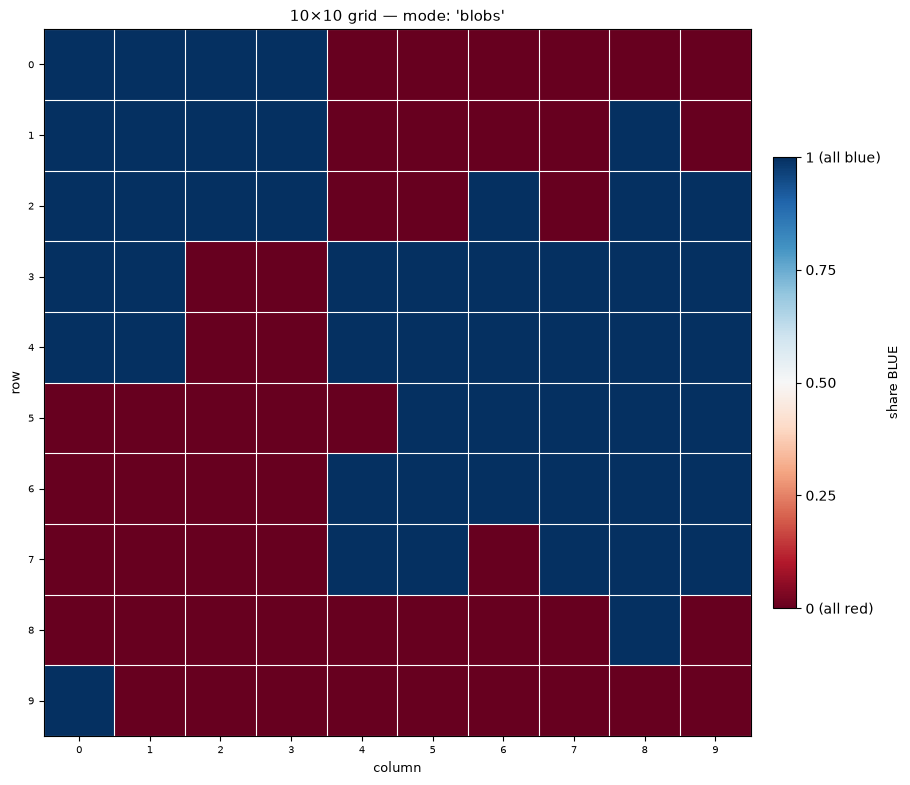

In [151]:
visualize_grid(G, ROWS, COLS)

## Segregation Metrics

Calls the individual functions from `pipeline/metrics.py` and collects results in a dict.  
**x group** = BLUE &nbsp;|&nbsp; **y group** = RED

Metrics computed: `edge_exact`, `half_edge_exact` (all λ), `e_assort`, `he_assort`, `dissimilarity_1`, `moran_P`.

In [152]:
def compute_metrics(G, x_col=X_COL, y_col=Y_COL, tot_col=TOT_COL):
    """
    Run selected pipeline/metrics.py functions on G.

    Computes: edge_exact, half_edge_exact (all λ), assortativity,
              dissimilarity_1, moran_P.

    Returns a flat dict {metric_name: value}.
    """
    results = {}

    # ── edge_exact and half_edge_exact across all λ ───────────────────────────
    for lam in [1]: #[0, 0.5, 1, 2, 10, None]:
        s = "lim" if lam is None else str(lam)

        ses = m.skew_exact(G, x_col, y_col, lam=lam)
        seo = m.skew_exact(G, y_col, x_col, lam=lam)
        results[f"skew_self_exact_{s}"]  = ses
        results[f"skew_other_exact_{s}"] = seo
        results[f"edge_exact_{s}"]       = 0.5 * (ses + seo)

        spes = m.skew_prime_exact(G, x_col, y_col, lam=lam)
        speo = m.skew_prime_exact(G, y_col, x_col, lam=lam)
        results[f"skew'_self_exact_{s}"]  = spes
        results[f"skew'_other_exact_{s}"] = speo
        results[f"half_edge_exact_{s}"]   = 0.5 * (spes + speo)

    # ── Assortativity ─────────────────────────────────────────────────────────
    # NOTE: assortativity() adds 'x_maj' / 'y_maj' attributes to graph nodes
    try:
        e_assort, he_assort = m.assortativity(G, x_col, y_col)
    except ZeroDivisionError:
        e_assort = he_assort = float("nan")
    results["e_assort"]  = e_assort
    results["he_assort"] = he_assort

    # ── Dissimilarity ─────────────────────────────────────────────────────────
    results["dissimilarity_1"] = m.dissimilarity(G, x_col, y_col, 1)

    # ── Moran's I (P-weight / row-standardised adjacency) ─────────────────────
    try:
        results["moran_P"] = m.moran(G, x_col, tot_col)["moran_P"]
    except ZeroDivisionError:
        results["moran_P"] = float("nan")

    # ── Population summary ────────────────────────────────────────────────────
    tot  = m.property_sum(G, "TOTPOP")
    blue = m.property_sum(G, x_col)
    red  = m.property_sum(G, y_col)
    results["total_population"] = tot
    results["total_blue"]       = blue
    results["total_red"]        = red
    results["share_blue"]       = blue / tot
    results["share_red"]        = red  / tot
    results["total_nodes"]      = G.number_of_nodes()
    results["total_edges"]      = G.number_of_edges()

    return results

In [153]:
results = compute_metrics(G)
print(f"Computed {len(results)} metrics.")

Computed 17 metrics.


In [154]:
# ── Display results grouped by type ───────────────────────────────────────────

GROUPS = [
    ("Population summary", [
        "total_population", "total_blue", "total_red",
        "share_blue", "share_red", "total_nodes", "total_edges",
    ]),
    ("Dissimilarity / Moran's I", ["dissimilarity_1", "moran_P"]),
    ("Assortativity", ["e_assort", "he_assort"]),
    ("Edge exact / Half-edge exact (λ=1)", [
        "skew_self_exact_1", "skew_other_exact_1", "edge_exact_1",
        "skew'_self_exact_1", "skew'_other_exact_1", "half_edge_exact_1",
    ]),
    ("Edge exact / Half-edge exact (λ→∞)", [
        "skew_self_exact_lim", "skew_other_exact_lim", "edge_exact_lim",
        "skew'_self_exact_lim", "skew'_other_exact_lim", "half_edge_exact_lim",
    ]),
]

def _fmt(v):
    if isinstance(v, float):
        return f"{v:.6f}"
    return str(v)

for group_title, keys in GROUPS:
    rows_out = [(k, _fmt(results[k])) for k in keys if k in results]
    if not rows_out:
        continue
    max_k = max(len(k) for k, _ in rows_out)
    print(f"\n{'━' * (max_k + 16)}")
    print(f"  {group_title}")
    print(f"{'─' * (max_k + 16)}")
    for k, v in rows_out:
        print(f"  {k:<{max_k}}  {v:>12}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Population summary
────────────────────────────────
  total_population         10000
  total_blue                5000
  total_red                 5000
  share_blue            0.500000
  share_red             0.500000
  total_nodes                100
  total_edges                180

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dissimilarity / Moran's I
───────────────────────────────
  dissimilarity_1      1.000000
  moran_P              0.576667

━━━━━━━━━━━━━━━━━━━━━━━━━
  Assortativity
─────────────────────────
  e_assort       0.643769
  he_assort      0.783273

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Edge exact / Half-edge exact (λ=1)
───────────────────────────────────
  skew_self_exact_1        0.712707
  skew_other_exact_1       0.706215
  edge_exact_1             0.709461
  skew'_self_exact_1       0.832258
  skew'_other_exact_1      0.827815
  half_edge_exact_1        0.830036


In [155]:
# ── edge_exact and half_edge_exact across all λ ───────────────────────────────

lam_labels  = ["0", "0.5", "1", "2", "10", "lim"]
metric_keys = ["edge_exact", "half_edge_exact"]

header = f"{'λ':>5}  " + "  ".join(f"{k:>18}" for k in metric_keys)
print(header)
print("─" * len(header))
for lam in lam_labels:
    row_vals = [results.get(f"{k}_{lam}", float("nan")) for k in metric_keys]
    print(f"{lam:>5}  " + "  ".join(f"{v:>18.6f}" for v in row_vals))

    λ          edge_exact     half_edge_exact
─────────────────────────────────────────────
    0                 nan                 nan
  0.5                 nan                 nan
    1            0.709461            0.830036
    2                 nan                 nan
   10                 nan                 nan
  lim                 nan                 nan
